# Eigenvalues, Eigenvectors และ Singular Value Decomposition (SVD) สำหรับ Machine Learning — เรียนด้วย NumPy ทีละขั้น

**ระดับ:** ปานกลาง • **เวลาประมาณ:** 90–120 นาที แบ่งเรียนได้ 3 รอบ • **ภาษา:** ไทย พร้อมศัพท์อังกฤษที่ใช้จริง

บทเรียนนี้ใช้ตัวอย่าง โค้ด และภาพที่สร้างขึ้นใหม่ทั้งหมด เพื่ออธิบายแนวคิดจากบทความอ้างอิงด้วยการลงมือคำนวณ:
eigenvalue/eigenvector → diagonalization → เหตุผลที่ต้องมี SVD → SVD ทีละขั้น → การนำไปใช้จริง
ไม่ได้แปลหรือคัดลอกบทความอ้างอิงทั้งฉบับ

**ก่อนเริ่ม:** ควรผ่าน `01_vectors_and_matrices.ipynb` และ `02_matrix_operations.ipynb` มาก่อน
(คุ้นเคยกับ shape, matrix multiplication, transpose) เลือก kernel `.venv` ของโครงการ
แล้วใช้ **Restart Kernel → Run All** โค้ดใช้เฉพาะแพ็กเกจที่มีในโครงการ ไม่ต้องดาวน์โหลดข้อมูล
รันตามลำดับ เพราะเซลล์ถัดไปใช้ตัวแปรจากเซลล์ก่อนหน้า

เมื่อเรียนจบ คุณควรอธิบายได้ว่า:
1. eigenvalue กับ eigenvector คืออะไร และ $Av=\lambda v$ หมายความว่าอย่างไร
2. diagonalization ($A=PDP^{-1}$) คืออะไร และทำไมใช้ได้เฉพาะเมทริกซ์จัตุรัสบางแบบ
3. ทำไม ML ต้องใช้ SVD แทน eigendecomposition กับเมทริกซ์ข้อมูลทั่วไป
4. $U$, $\Sigma$, $V^\top$ ใน $A=U\Sigma V^\top$ แต่ละตัวหมายถึงอะไร และคำนวณด้วยมือได้อย่างไร
5. ใช้ SVD บีบอัดข้อมูล ลด noise และแก้ pseudo-inverse/least squares
6. ใช้ SVD ลดมิติข้อมูล (dimensionality reduction) และเทียบกับ `sklearn.decomposition.TruncatedSVD`

**เส้นทาง:** ส่วน 1–3 eigen พื้นฐาน → ส่วน 4–7 SVD คืออะไรและคำนวณอย่างไร →
ส่วน 8–11 การนำไปใช้จริง → ส่วน 12–13 สรุปและแบบฝึกหัด

## 1. เตรียมเครื่องมือ

ใช้ `numpy.linalg` สำหรับ eigendecomposition และ SVD, `sklearn.decomposition.TruncatedSVD`
สำหรับเทียบผลกับไลบรารีมาตรฐานในส่วนท้าย กำหนด seed เพื่อให้ข้อมูลสุ่มทำซ้ำได้

ชื่อในโค้ดใช้ภาษาอังกฤษเพื่ออ่านเอกสารต่อได้ง่าย คำอธิบายและคำถามเป็นภาษาไทย
กราฟจะใช้ฟอนต์ไทยที่ติดตั้งในเครื่อง หากไม่มีจะเปลี่ยนป้ายกราฟเป็นภาษาอังกฤษอัตโนมัติ

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager
from matplotlib.patches import FancyArrowPatch
from sklearn.decomposition import TruncatedSVD

SEED = 42
np.set_printoptions(precision=3, suppress=True)
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
thai_font = next(
    (
        name
        for name in ["Noto Sans Thai", "Tahoma", "Thonburi", "Sukhumvit Set"]
        if name in available_fonts
    ),
    None,
)
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11, "axes.unicode_minus": False})
if thai_font:
    plt.rcParams["font.family"] = thai_font


def label(thai, english):
    return thai if thai_font else english


print("NumPy:", np.__version__)
print("ฟอนต์สำหรับกราฟ:", thai_font or "English fallback")

NumPy: 2.5.3
ฟอนต์สำหรับกราฟ: Tahoma


## 2. Eigenvalue และ Eigenvector คืออะไร

เมทริกซ์สี่เหลี่ยมจัตุรัส $A$ แปลง vector $v$ ไปเป็น $Av$ โดยทั่วไปทิศทางจะเปลี่ยน
แต่บาง vector พิเศษที่แปลงแล้ว **ทิศทางเดิม เปลี่ยนแค่ความยาว (หรือกลับทิศ)**:

$$Av = \lambda v, \qquad v \neq 0$$

$v$ เรียกว่า **eigenvector** และสเกลาร์ $\lambda$ ที่คู่กันเรียกว่า **eigenvalue**
eigenvector ไม่มีขนาดตายตัว (คูณด้วยสเกลาร์ใดๆ ก็ยังเป็น eigenvector เดิม) จึงมักปรับให้เป็น unit vector

**Use case:** ทิศทางที่ข้อมูลกระจายมากที่สุด (แนวคิดเดียวกับที่ PCA ใช้ใน Phase 08),
การวิเคราะห์เสถียรภาพของระบบพลวัต และเป็นส่วนประกอบสำคัญของ SVD ที่จะเรียนต่อในบทเรียนนี้

อ้างอิง: [Wikipedia — Eigenvalues and eigenvectors](https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors)

In [2]:
# ตัวอย่างที่ตรวจด้วยมือได้ก่อน: A สมมาตร มี eigenvalue 3 และ 1
A_eig = np.array([[2.0, 1.0], [1.0, 2.0]])
v1 = np.array([1.0, 1.0]) / np.sqrt(2)
v2 = np.array([1.0, -1.0]) / np.sqrt(2)
np.testing.assert_allclose(A_eig @ v1, 3.0 * v1)
np.testing.assert_allclose(A_eig @ v2, 1.0 * v2)
print("ตรวจด้วยมือผ่าน: Av1 = 3v1 และ Av2 = 1v2")

eigenvalues, eigenvectors = np.linalg.eig(A_eig)
print("eigenvalues จาก np.linalg.eig:", eigenvalues)
print("ส่วนจินตภาพเป็นศูนย์เพราะ A_eig สมมาตร; ถ้ารู้ล่วงหน้าว่าสมมาตรควรใช้ np.linalg.eigh แทน")
for i in range(len(eigenvalues)):
    np.testing.assert_allclose(
        A_eig @ eigenvectors[:, i], eigenvalues[i] * eigenvectors[:, i], atol=1e-10
    )
print("ตรวจสอบผ่าน: Av = λv ทุกคู่ eigenvalue/eigenvector ที่ NumPy คำนวณได้")

ตรวจด้วยมือผ่าน: Av1 = 3v1 และ Av2 = 1v2
eigenvalues จาก np.linalg.eig: [3.+0.j 1.+0.j]
ส่วนจินตภาพเป็นศูนย์เพราะ A_eig สมมาตร; ถ้ารู้ล่วงหน้าว่าสมมาตรควรใช้ np.linalg.eigh แทน
ตรวจสอบผ่าน: Av = λv ทุกคู่ eigenvalue/eigenvector ที่ NumPy คำนวณได้


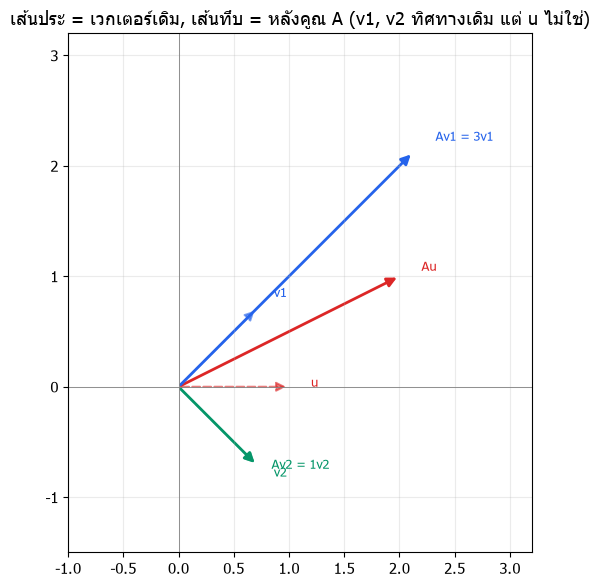

In [3]:
u_arbitrary = np.array([1.0, 0.0])
transformed_u = A_eig @ u_arbitrary
transformed_v1 = A_eig @ v1
transformed_v2 = A_eig @ v2

fig, ax = plt.subplots(figsize=(6, 6))
originals = [(u_arbitrary, "#dc2626", "u"), (v1, "#2563eb", "v1"), (v2, "#059669", "v2")]
transformed = [
    (transformed_u, "#dc2626", "Au"),
    (transformed_v1, "#2563eb", "Av1 = 3v1"),
    (transformed_v2, "#059669", "Av2 = 1v2"),
]
for vec, color, name in originals:
    ax.add_patch(
        FancyArrowPatch(
            (0, 0),
            vec,
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=1.5,
            color=color,
            linestyle="dashed",
            alpha=0.6,
        )
    )
    ax.text(vec[0] * 1.15 + 0.05, vec[1] * 1.15, name, color=color, fontsize=9)
for vec, color, name in transformed:
    ax.add_patch(
        FancyArrowPatch((0, 0), vec, arrowstyle="-|>", mutation_scale=14, linewidth=2, color=color)
    )
    ax.text(vec[0] * 1.05 + 0.1, vec[1] * 1.05, name, color=color, fontsize=9)
ax.set_xlim(-1, 3.2)
ax.set_ylim(-1.5, 3.2)
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.6)
ax.axvline(0, color="gray", linewidth=0.6)
ax.grid(alpha=0.25)
ax.set_title(
    label(
        "เส้นประ = เวกเตอร์เดิม, เส้นทึบ = หลังคูณ A (v1, v2 ทิศทางเดิม แต่ u ไม่ใช่)",
        "Dashed = original, solid = after A (v1, v2 keep direction; u does not)",
    )
)
plt.tight_layout()
plt.show()

## 3. Diagonalization — A = PDP⁻¹

ถ้าเมทริกซ์สี่เหลี่ยมจัตุรัส $A$ ขนาด $n\times n$ มี eigenvector ที่เป็นอิสระเชิงเส้นครบ $n$ ตัว
(**diagonalizable**) จะเขียนได้เป็น

$$A = PDP^{-1}$$

โดย $P$ คือเมทริกซ์ที่แต่ละคอลัมน์เป็น eigenvector และ $D$ คือเมทริกซ์ทแยงมุมของ eigenvalue ที่คู่กัน
ไม่ใช่ทุกเมทริกซ์จะ diagonalizable (เช่น มี eigenvalue ซ้ำแต่ eigenvector อิสระไม่ครบมิติ)
และการแยกแบบนี้ใช้ได้เฉพาะเมทริกซ์ **สี่เหลี่ยมจัตุรัส** เท่านั้น

**Use case — ยกกำลังเมทริกซ์อย่างรวดเร็ว:** $A^k = PD^kP^{-1}$ เพราะ $D$ เป็นทแยงมุม
ยกกำลังทีละสมาชิกได้เลย แทนที่จะคูณเมทริกซ์ $k$ ครั้งตรงๆ

อ้างอิง: [Wikipedia — Eigendecomposition of a matrix](https://en.wikipedia.org/wiki/Eigendecomposition_of_a_matrix)

In [4]:
P = eigenvectors
D = np.diag(eigenvalues)
A_reconstructed = P @ D @ np.linalg.inv(P)
np.testing.assert_allclose(A_reconstructed, A_eig, atol=1e-10)
print("A จาก P D P^-1:\n", A_reconstructed.real)

k = 5
A_power_direct = np.linalg.matrix_power(A_eig, k)
A_power_via_D = P @ np.diag(eigenvalues**k) @ np.linalg.inv(P)
np.testing.assert_allclose(A_power_direct, A_power_via_D, atol=1e-6)
print(f"A^{k} ตรงกันทั้งสองวิธี:\n", A_power_direct)

A จาก P D P^-1:
 [[2. 1.]
 [1. 2.]]
A^5 ตรงกันทั้งสองวิธี:
 [[122. 121.]
 [121. 122.]]


## 4. ทำไมต้องมี SVD

eigendecomposition ใช้ได้เฉพาะเมทริกซ์สี่เหลี่ยมจัตุรัสที่ diagonalizable เท่านั้น
แต่ข้อมูลจริงในงาน ML มักเป็นเมทริกซ์สี่เหลี่ยมผืนผ้า $n \times d$ (จำนวนตัวอย่าง ≠ จำนวน feature)
เช่นเดียวกับ `X` ในบทเรียนก่อนหน้า ซึ่งไม่มี eigenvalue/eigenvector ในความหมายเดิมด้วยซ้ำ

**Singular Value Decomposition (SVD)** เป็นการแยกเมทริกซ์ที่ใช้ได้กับ **เมทริกซ์ใดก็ได้**
ไม่จำกัดว่าต้องเป็นเมทริกซ์จัตุรัสหรือ diagonalizable และเป็นพื้นฐานของหลายเทคนิคใน ML เช่น
การลดมิติข้อมูล (dimensionality reduction), การบีบอัดข้อมูล และการลดสัญญาณรบกวน (noise removal)

อ้างอิง: [Wikipedia — Singular value decomposition](https://en.wikipedia.org/wiki/Singular_value_decomposition)

In [5]:
X_rect = np.array([[80.0, 2.0, 5.0], [120.0, 3.0, 2.0], [60.0, 1.0, 10.0], [150.0, 4.0, 1.0]])
try:
    np.linalg.eig(X_rect)
except np.linalg.LinAlgError as error:
    print("np.linalg.eig ใช้กับเมทริกซ์ไม่จัตุรัสไม่ได้:", error)
print("X_rect shape:", X_rect.shape, "→ ต้องใช้ SVD แทน eigendecomposition")

np.linalg.eig ใช้กับเมทริกซ์ไม่จัตุรัสไม่ได้: Last 2 dimensions of the array must be square
X_rect shape: (4, 3) → ต้องใช้ SVD แทน eigendecomposition


## 5. SVD คืออะไร — A = UΣVᵀ

สำหรับเมทริกซ์จริง $A$ ขนาด $m \times n$ ใดๆ จะแยกได้เสมอเป็น

$$A = U \Sigma V^\top$$

- $U$ ขนาด $m \times m$ เป็น **orthogonal matrix** ($U^\top U = I$) — คอลัมน์คือ left-singular vectors
- $\Sigma$ ขนาด $m \times n$ เป็นเมทริกซ์ทแยงมุม (ค่านอกแนวทแยงเป็นศูนย์) ค่าบนแนวทแยง
  $\sigma_1 \ge \sigma_2 \ge \dots \ge 0$ เรียกว่า **singular values**
- $V$ ขนาด $n \times n$ เป็น orthogonal matrix ($V^\top V = I$) — คอลัมน์คือ right-singular vectors

**ความหมายเชิงเรขาคณิต:** การแปลงด้วย $A$ เทียบเท่ากับหมุน/สะท้อนด้วย $V^\top$ →
ยืด/หดตามแกนด้วย $\Sigma$ → หมุน/สะท้อนอีกครั้งด้วย $U$

singular value สัมพันธ์กับ eigenvalue ของ $A^\top A$ (เมทริกซ์จัตุรัสเสมอ ไม่ว่า $A$ จะเป็นรูปทรงใด):

$$A^\top A = V \Sigma^\top \Sigma V^\top \quad\Rightarrow\quad \sigma_i = \sqrt{\lambda_i(A^\top A)}$$

อ้างอิง: [Wikipedia — Singular value decomposition](https://en.wikipedia.org/wiki/Singular_value_decomposition)

In [6]:
A_svd_demo = np.array([[3.0, 1.0], [1.0, 3.0], [1.0, 1.0]])  # 3x2, m > n
U, singular_values, Vt = np.linalg.svd(A_svd_demo)
print("A shape:", A_svd_demo.shape)
print("U shape:", U.shape, "; singular values:", singular_values, "; Vt shape:", Vt.shape)
np.testing.assert_allclose(U.T @ U, np.eye(U.shape[0]), atol=1e-10)
np.testing.assert_allclose(Vt @ Vt.T, np.eye(Vt.shape[0]), atol=1e-10)

Sigma = np.zeros_like(A_svd_demo)
np.fill_diagonal(Sigma, singular_values)
np.testing.assert_allclose(U @ Sigma @ Vt, A_svd_demo, atol=1e-10)
print("U และ V มีคอลัมน์ orthonormal และ U Σ Vᵀ คืนค่า A ได้พอดี")

A shape: (3, 2)
U shape: (3, 3) ; singular values: [4.243 2.   ] ; Vt shape: (2, 2)
U และ V มีคอลัมน์ orthonormal และ U Σ Vᵀ คืนค่า A ได้พอดี


## 6. คำนวณ SVD ทีละขั้นด้วยมือ

ขั้นตอน:
1. คำนวณ $A^\top A$ (เมทริกซ์จัตุรัสสมมาตรขนาด $n \times n$ เสมอ)
2. หา eigenvalue/eigenvector ของ $A^\top A$ ด้วย `np.linalg.eigh` (สำหรับเมทริกซ์สมมาตรโดยเฉพาะ)
   → ได้ $V$ (right-singular vectors) และ $\sigma_i = \sqrt{\lambda_i}$ (เรียงจากมากไปน้อย)
3. หา $U$ จาก $u_i = \dfrac{1}{\sigma_i} A v_i$ สำหรับ $\sigma_i \neq 0$

eigenvector มีทิศทางไม่ตายตัว (คูณ −1 ก็ยังเป็น eigenvector เดิม) NumPy กับการคำนวณด้วยมือ
จึงอาจได้เครื่องหมายต่างกัน แต่ $A = U\Sigma V^\top$ ต้องให้ผลลัพธ์เดียวกันเสมอหลังปรับเครื่องหมายให้ตรงกัน

In [7]:
A_manual = np.array([[3.0, 1.0], [1.0, 3.0], [1.0, 1.0]])

# ขั้นตอน 1-2: eigendecomposition ของ A^T A (สมมาตรเสมอ ใช้ eigh แม่นยำ/เร็วกว่า eig)
AtA = A_manual.T @ A_manual
eigvals, eigvecs = np.linalg.eigh(AtA)
order = np.argsort(eigvals)[::-1]  # เรียงจากมากไปน้อย
V_manual = eigvecs[:, order]
singular_values_manual = np.sqrt(np.clip(eigvals[order], 0, None))

# ขั้นตอน 3: หา U จาก A v_i / sigma_i
U_manual = (A_manual @ V_manual) / singular_values_manual
print("singular values (คำนวณด้วยมือ):", singular_values_manual)

U_np, s_np, Vt_np = np.linalg.svd(A_manual, full_matrices=False)
np.testing.assert_allclose(singular_values_manual, s_np, atol=1e-10)

# ปรับเครื่องหมายให้ตรงกันก่อนเทียบ U, V แบบสมาชิกต่อสมาชิก
sign = np.sign(np.sum(U_manual * U_np, axis=0))
sign[sign == 0] = 1.0
U_manual_aligned = U_manual * sign
V_manual_aligned = V_manual * sign
np.testing.assert_allclose(U_manual_aligned, U_np, atol=1e-8)
np.testing.assert_allclose(V_manual_aligned, Vt_np.T, atol=1e-8)

Sigma_manual = np.diag(singular_values_manual)
np.testing.assert_allclose(
    U_manual_aligned @ Sigma_manual @ V_manual_aligned.T, A_manual, atol=1e-8
)
print("SVD ที่คำนวณด้วยมือ ตรงกับ np.linalg.svd (หลังปรับเครื่องหมาย)")

singular values (คำนวณด้วยมือ): [4.243 2.   ]
SVD ที่คำนวณด้วยมือ ตรงกับ np.linalg.svd (หลังปรับเครื่องหมาย)


## 7. Full vs Reduced SVD ใน NumPy

`np.linalg.svd(A, full_matrices=True)` (ค่าเริ่มต้น) คืน $U$ ขนาด $m\times m$, $V^\top$ ขนาด $n\times n$
เต็มรูป แต่ถ้า $m \neq n$ จะมีคอลัมน์/แถวส่วนเกินที่ไม่จำเป็นสำหรับสร้าง $A$ กลับคืน
`full_matrices=False` (economy/reduced SVD) คืนเฉพาะส่วนที่จำเป็น ประหยัดหน่วยความจำกว่า
โดยเฉพาะเมื่อ $m \gg n$ หรือ $n \gg m$ ซึ่งพบบ่อยในข้อมูลจริง (เช่น จำนวนแถวมากกว่าคอลัมน์มาก)

In [8]:
tall = np.random.default_rng(SEED).normal(size=(6, 3))  # m > n
wide = tall.T  # n > m

for name, matrix in [("tall (6x3)", tall), ("wide (3x6)", wide)]:
    U_full, s_full, Vt_full = np.linalg.svd(matrix, full_matrices=True)
    U_econ, s_econ, Vt_econ = np.linalg.svd(matrix, full_matrices=False)
    print(
        f"{name}: full U{U_full.shape} Vt{Vt_full.shape} | reduced U{U_econ.shape} Vt{Vt_econ.shape}"
    )
    k = min(matrix.shape)
    np.testing.assert_allclose(U_full[:, :k] @ np.diag(s_full) @ Vt_full[:k, :], matrix, atol=1e-8)
    np.testing.assert_allclose(U_econ @ np.diag(s_econ) @ Vt_econ, matrix, atol=1e-8)
print("ทั้งสองรูปแบบสร้าง A กลับคืนได้เหมือนกัน ต่างกันแค่ขนาดเมทริกซ์ที่เก็บ")

tall (6x3): full U(6, 6) Vt(3, 3) | reduced U(6, 3) Vt(3, 3)
wide (3x6): full U(3, 3) Vt(6, 6) | reduced U(3, 3) Vt(3, 6)
ทั้งสองรูปแบบสร้าง A กลับคืนได้เหมือนกัน ต่างกันแค่ขนาดเมทริกซ์ที่เก็บ


## 8. Rank, Low-rank Approximation และการบีบอัดข้อมูล

ทฤษฎีบท Eckart–Young–Mirsky: การประมาณ $A$ ด้วยเมทริกซ์ rank $k$ ที่ดีที่สุด (วัดด้วย Frobenius norm)
คือการเก็บเฉพาะ $k$ singular value ที่มากที่สุด:

$$A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^\top$$

ยิ่ง singular value ลำดับหลังมีค่าน้อย ยิ่งตัดทิ้งได้โดยเสียข้อมูลน้อย
นี่คือหลักการเบื้องหลังการบีบอัดภาพและการลดมิติข้อมูล (PCA ใช้หลักการเดียวกัน จะเรียนใน Phase 08)

**Use case — บีบอัดภาพ:** ภาพระดับเทาคือเมทริกซ์ตัวเลข ใช้ $k$ singular value แรกเก็บภาพโดยประมาณ
เก็บแค่ $U_k$ ($m\times k$), $\Sigma_k$ ($k$ ค่า) และ $V_k^\top$ ($k\times n$) แทนเมทริกซ์เต็ม $m\times n$

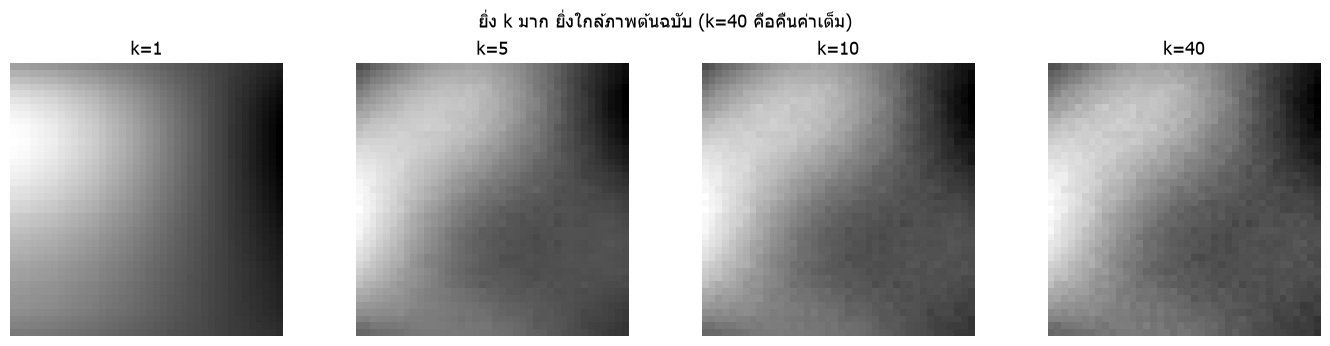

In [9]:
def reconstruct(U, s, Vt, k):
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]


rng = np.random.default_rng(SEED)
size = 40
gradient = np.linspace(0, 1, size)
# ภาพจำลองที่มีโครงสร้างเป็นคลื่นซ้อนกัน 2 ความถี่ บวก noise เล็กน้อยให้สมจริง
image_matrix = np.outer(np.sin(gradient * 3), np.cos(gradient * 2)) + 0.5 * np.outer(
    np.cos(gradient * 5), np.sin(gradient * 4)
)
image_matrix += rng.normal(0, 0.02, size=image_matrix.shape)

U_img, s_img, Vt_img = np.linalg.svd(image_matrix, full_matrices=False)
full_reconstruction = reconstruct(U_img, s_img, Vt_img, size)
np.testing.assert_allclose(full_reconstruction, image_matrix, atol=1e-8)

ks = [1, 5, 10, size]
fig, axes = plt.subplots(1, len(ks), figsize=(14, 3.5))
for ax, k in zip(axes, ks):
    approx = reconstruct(U_img, s_img, Vt_img, k)
    ax.imshow(approx, cmap="gray")
    ax.set_title(f"k={k}")
    ax.axis("off")
fig.suptitle(
    label(
        "ยิ่ง k มาก ยิ่งใกล้ภาพต้นฉบับ (k=40 คือคืนค่าเต็ม)",
        "Larger k approximates the original more closely (k=40 is exact)",
    )
)
plt.tight_layout()
plt.show()

จำนวนค่าต้นฉบับ: 1600, หลังบีบอัด (k=5): 405
อัตราส่วนบีบอัด: 3.95 เท่า
ความคลาดเคลื่อนสัมพัทธ์ (Frobenius norm): 0.0406


/var/folders/h_/n_3fs8zd6qs13gg2qhy4yzw40000gn/T/ipykernel_73161/305001653.py:20: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Tahoma.
  plt.tight_layout()
/Users/ittichaib/Documents/GitHub/ml-learning-lab/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Tahoma.
  fig.canvas.print_figure(bytes_io, **kw)


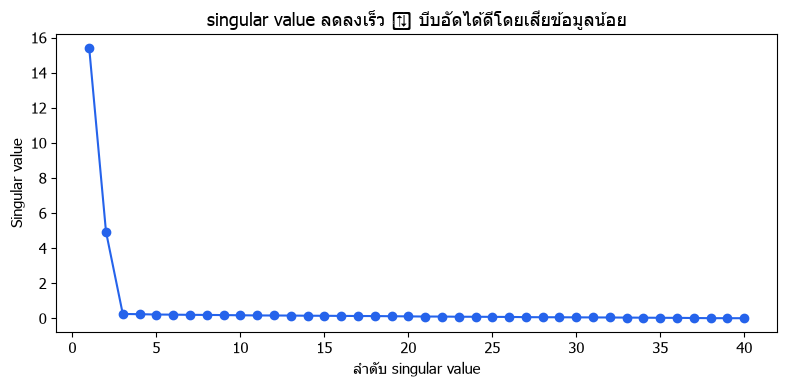

In [10]:
k_compress = 5
approx_5 = reconstruct(U_img, s_img, Vt_img, k_compress)
original_numbers = image_matrix.size
compressed_numbers = k_compress * (U_img.shape[0] + Vt_img.shape[1] + 1)
compression_ratio = original_numbers / compressed_numbers
frobenius_error = np.linalg.norm(image_matrix - approx_5) / np.linalg.norm(image_matrix)
print(f"จำนวนค่าต้นฉบับ: {original_numbers}, หลังบีบอัด (k={k_compress}): {compressed_numbers}")
print(f"อัตราส่วนบีบอัด: {compression_ratio:.2f} เท่า")
print(f"ความคลาดเคลื่อนสัมพัทธ์ (Frobenius norm): {frobenius_error:.4f}")
assert compression_ratio > 1
assert frobenius_error < 0.5

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(s_img) + 1), s_img, "o-", color="#2563eb")
ax.set_xlabel(label("ลำดับ singular value", "Singular value index"))
ax.set_ylabel("Singular value")
ax.set_title(
    label("singular value ลดลงเร็ว → บีบอัดได้ดีโดยเสียข้อมูลน้อย", "Fast decay enables good compression")
)
plt.tight_layout()
plt.show()

## 9. SVD สำหรับลดสัญญาณรบกวน (Denoising)

ถ้าข้อมูลจริงมีโครงสร้าง rank ต่ำ (เช่น เกิดจากปัจจัยแฝงไม่กี่ตัว) แต่มี noise แบบสุ่มเติมเข้ามา
noise มักกระจายอยู่ใน singular value ลำดับท้ายๆ ใกล้เคียงกันทุกทิศทาง
การตัด singular value ท้ายๆ ทิ้ง (truncated SVD) จึงช่วยลด noise โดยยังคงโครงสร้างหลักไว้

**คำเตือน:** วิธีนี้ได้ผลเมื่อสัญญาณจริงมี rank ต่ำกว่าข้อมูลที่สังเกตได้ชัดเจน
ถ้าเลือก $k$ มากเกินไปจะเก็บ noise ไว้ด้วย ถ้าน้อยเกินไปจะทิ้งสัญญาณจริงไปด้วย

MSE ก่อนลด noise (สัญญาณดิบเทียบสัญญาณจริง): 0.2574
MSE หลังลด noise ด้วย SVD (k=2): 0.0396
SVD ช่วยลด noise ได้ เพราะรู้ว่าสัญญาณจริงมี rank ต่ำ


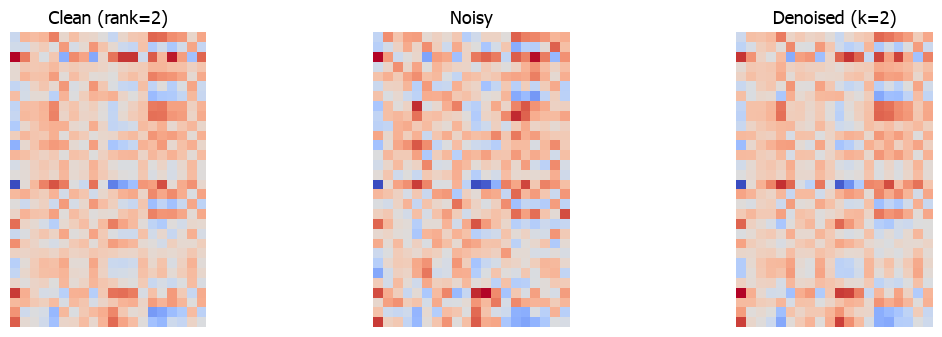

In [11]:
rng = np.random.default_rng(SEED)
n_rows, n_cols, true_rank = 30, 20, 2
# สร้างสัญญาณจริงที่มี rank ต่ำโดยตั้งใจ: คูณเมทริกซ์เล็ก 2 ตัว
factor_left = rng.normal(size=(n_rows, true_rank))
factor_right = rng.normal(size=(true_rank, n_cols))
clean_signal = factor_left @ factor_right
noisy_signal = clean_signal + rng.normal(0, 0.5, size=clean_signal.shape)
assert np.linalg.matrix_rank(clean_signal) == true_rank

U_n, s_n, Vt_n = np.linalg.svd(noisy_signal, full_matrices=False)
denoised_signal = reconstruct(U_n, s_n, Vt_n, true_rank)

mse_noisy = np.mean((noisy_signal - clean_signal) ** 2)
mse_denoised = np.mean((denoised_signal - clean_signal) ** 2)
print(f"MSE ก่อนลด noise (สัญญาณดิบเทียบสัญญาณจริง): {mse_noisy:.4f}")
print(f"MSE หลังลด noise ด้วย SVD (k={true_rank}): {mse_denoised:.4f}")
assert mse_denoised < mse_noisy
print("SVD ช่วยลด noise ได้ เพราะรู้ว่าสัญญาณจริงมี rank ต่ำ")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
vmin, vmax = clean_signal.min(), clean_signal.max()
for ax, matrix, title in zip(
    axes,
    [clean_signal, noisy_signal, denoised_signal],
    ["Clean (rank=2)", "Noisy", f"Denoised (k={true_rank})"],
):
    ax.imshow(matrix, cmap="coolwarm", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 10. SVD กับ Pseudo-inverse และ Least Squares

Moore–Penrose pseudo-inverse $A^+$ นิยามจาก SVD โดยตรง:

$$A = U\Sigma V^\top \quad\Rightarrow\quad A^+ = V \Sigma^+ U^\top$$

โดย $\Sigma^+$ ได้จากการกลับค่าที่ไม่เป็นศูนย์บนแนวทแยงของ $\Sigma$ (ค่าที่เป็นศูนย์หรือใกล้ศูนย์มาก
ให้เป็นศูนย์ต่อ เพื่อความเสถียรเชิงตัวเลข) ใช้แก้ปัญหา least squares
$\min_\theta \|X\theta - y\|_2^2$ ได้แม้ $X^\top X$ จะ singular หรือใกล้ singular
`np.linalg.lstsq` ที่ใช้ในบทเรียนก่อนหน้า ก็คำนวณผ่าน SVD ภายใน

In [12]:
X_design = np.array(
    [
        [1.0, 80.0, 2.0, 5.0],
        [1.0, 120.0, 3.0, 2.0],
        [1.0, 60.0, 1.0, 10.0],
        [1.0, 150.0, 4.0, 1.0],
        [1.0, 95.0, 2.0, 8.0],
    ]
)
y_design = np.array([2.7, 4.1, 1.8, 5.2, 3.0])

U_p, s_p, Vt_p = np.linalg.svd(X_design, full_matrices=False)
s_inv = np.where(s_p > 1e-10, 1.0 / s_p, 0.0)
X_pinv_manual = Vt_p.T @ np.diag(s_inv) @ U_p.T
theta_svd = X_pinv_manual @ y_design

X_pinv_numpy = np.linalg.pinv(X_design)
np.testing.assert_allclose(X_pinv_manual, X_pinv_numpy, atol=1e-8)

theta_lstsq, residual_lstsq, rank_lstsq, _ = np.linalg.lstsq(X_design, y_design, rcond=None)
np.testing.assert_allclose(theta_svd, theta_lstsq, atol=1e-8)
display(
    pd.DataFrame(
        {
            "parameter": ["bias", "area_m2", "bedrooms", "age_years"],
            "theta_pseudo_inverse": theta_svd,
            "theta_lstsq": theta_lstsq,
        }
    )
)
print("ตรงกัน: pseudo-inverse และ lstsq แก้ปัญหาเดียวกันด้วยกลไกเดียวกัน (SVD)")

,parameter,theta_pseudo_inverse,theta_lstsq
0,bias,0.186667,0.186667
1,area_m2,0.025333,0.025333
2,bedrooms,0.306667,0.306667
3,age_years,-0.023333,-0.023333


ตรงกัน: pseudo-inverse และ lstsq แก้ปัญหาเดียวกันด้วยกลไกเดียวกัน (SVD)


## 11. Mini-project: ลดมิติข้อมูลด้วย SVD

สร้างข้อมูลจำลอง 200 ตัวอย่าง 6 features แต่ features มีความสัมพันธ์กันสูง
(เกิดจากปัจจัยแฝงเพียง 2 ตัวเท่านั้น) เหมือนสถานการณ์จริงที่ feature หลายตัวสื่อข้อมูลซ้ำซ้อนกัน
ใช้ truncated SVD ฉาย (project) ข้อมูลลงพื้นที่มิติต่ำ แล้ววัดว่าเก็บความแปรปรวนได้กี่เปอร์เซ็นต์

การฉายข้อมูล: $Z = U_k \Sigma_k$ (เทียบเท่ากับ $Z = X_{centered} V_k$) มิติจาก $d=6$ เหลือ $k$
`sklearn.decomposition.TruncatedSVD` ไม่ทำ centering ให้อัตโนมัติ (ต่างจาก PCA)
จึงต้อง center ข้อมูลเองก่อน เพื่อให้ผลตรงกับการฉายด้วย SVD ตรงๆ

ลดจาก 6 มิติ เหลือ 2 มิติ, เก็บความแปรปรวนได้ 99.92%
ระยะห่างระหว่างจุดหลังฉายด้วยมือ ตรงกับ TruncatedSVD ของ sklearn


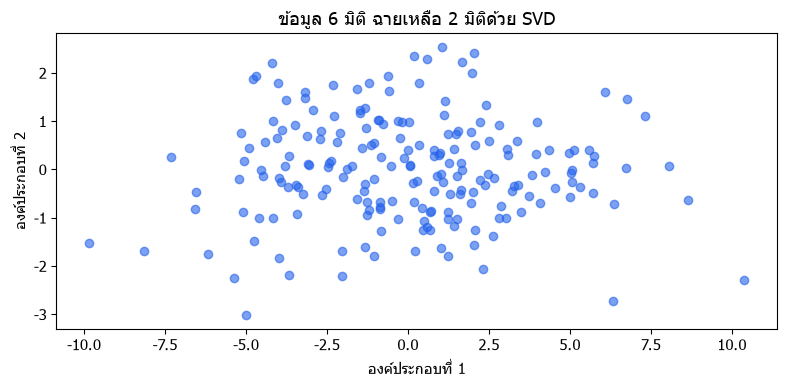

In [13]:
rng = np.random.default_rng(SEED)
n_samples, true_dims, observed_dims = 200, 2, 6
latent = rng.normal(size=(n_samples, true_dims))
mixing = rng.normal(size=(true_dims, observed_dims))
X_high_dim = latent @ mixing + rng.normal(0, 0.05, size=(n_samples, observed_dims))
X_centered = X_high_dim - X_high_dim.mean(axis=0, keepdims=True)

U_hd, s_hd, Vt_hd = np.linalg.svd(X_centered, full_matrices=False)
k = 2
Z_manual = U_hd[:, :k] * s_hd[:k]
np.testing.assert_allclose(Z_manual, X_centered @ Vt_hd[:k, :].T, atol=1e-8)

explained_ratio = (s_hd[:k] ** 2).sum() / (s_hd**2).sum()
print(f"ลดจาก {observed_dims} มิติ เหลือ {k} มิติ, เก็บความแปรปรวนได้ {explained_ratio:.2%}")

svd_sklearn = TruncatedSVD(n_components=k, random_state=SEED)
Z_sklearn = svd_sklearn.fit_transform(X_centered)


def pairwise_distances(Z):
    diff = Z[:, None, :] - Z[None, :, :]
    return np.sqrt((diff**2).sum(axis=-1))


# เทียบด้วยระยะห่างระหว่างจุด เพราะทิศทางแกน/เครื่องหมายอาจต่างกันระหว่างการคำนวณสองแบบ
np.testing.assert_allclose(pairwise_distances(Z_manual), pairwise_distances(Z_sklearn), atol=1e-6)
print("ระยะห่างระหว่างจุดหลังฉายด้วยมือ ตรงกับ TruncatedSVD ของ sklearn")

fig, ax = plt.subplots()
ax.scatter(Z_manual[:, 0], Z_manual[:, 1], alpha=0.6, color="#2563eb")
ax.set_xlabel(label("องค์ประกอบที่ 1", "Component 1"))
ax.set_ylabel(label("องค์ประกอบที่ 2", "Component 2"))
ax.set_title(
    label(f"ข้อมูล {observed_dims} มิติ ฉายเหลือ 2 มิติด้วย SVD", f"{observed_dims}D data projected to 2D")
)
plt.tight_layout()
plt.show()

## 12. แผนที่เชื่อมแนวคิดกับงานจริง

| แนวคิด | โค้ดสำคัญ | ตัวอย่างการใช้งาน |
|---|---|---|
| Eigenvalue / eigenvector | `np.linalg.eig`, `np.linalg.eigh` | ทิศทางที่เมทริกซ์ไม่เปลี่ยนทิศ |
| Diagonalization | `P @ D @ np.linalg.inv(P)` | ยกกำลังเมทริกซ์อย่างรวดเร็ว |
| SVD | `np.linalg.svd` | แยกเมทริกซ์ใดก็ได้เป็น U, Σ, Vᵀ |
| Low-rank approximation | `U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]` | บีบอัดภาพ/ข้อมูล |
| Denoising | ตัด singular value ท้ายๆ ทิ้ง | ลด noise โดยคงโครงสร้างหลักไว้ |
| Pseudo-inverse | `np.linalg.pinv`, `V Σ⁺ Uᵀ` | least squares ที่ไม่มี inverse ตรงๆ |
| Dimensionality reduction | `U[:, :k] * s[:k]`, `TruncatedSVD` | ลดจำนวน feature ที่ซ้ำซ้อนกัน |

**ก่อนใช้ SVD ทุกครั้ง:** เก็บ $k$ ค่าเพียงพอหรือยัง? กำลังตัด noise หรือกำลังตัดสัญญาณจริงทิ้ง?
เปรียบเทียบกับผลจากไลบรารีมาตรฐาน (`np.linalg.svd`, `sklearn`) แล้วหรือยัง?

## 13. แบบฝึกหัด — ลองก่อนเปิดเฉลย

ใช้ตัวแปรจากบทเรียนด้านบน และเปลี่ยนค่าในเซลล์ทดลองได้

1. ตรวจว่า `eigenvalues`/`eigenvectors` (ส่วน 2) ทุกคู่ยังสอดคล้องกับ $Av=\lambda v$
   โดยเขียน loop ตรวจเอง (ไม่ใช้ index ที่ผูกไว้แล้วในเนื้อหา)
2. เปลี่ยน `k_compress` ในส่วน 8 เป็น 1 และ 20 แล้วสังเกตว่า `frobenius_error` เปลี่ยนไปอย่างไร
3. เปลี่ยน noise scale ในส่วน 9 จาก `0.5` เป็น `2.0` แล้วรันใหม่ สังเกตว่า denoising ยังช่วยได้ไหม
4. ใช้ `X_design` และ `y_design` ในส่วน 10 คำนวณ residual `X_design @ theta_svd - y_design`
   แล้วตรวจว่าผลรวมกำลังสองของ residual เท่ากับค่าที่ `np.linalg.lstsq` คืนมาหรือไม่
5. ในส่วน 11 ลองเปลี่ยน `k` เป็น 3 แล้วดูว่า `explained_ratio` เพิ่มขึ้นเท่าไร

ตัวแปรที่ลงท้าย `_exercise` แยกจากตัวอย่างหลัก เพื่อทดลองโดยไม่เขียนทับข้อมูลเดิม

In [14]:
# พื้นที่ทดลอง: ลองเขียนโค้ดของคุณเองก่อนเปิดเฉลยด้านล่าง
k_compress_exercise = 1
approx_exercise = reconstruct(U_img, s_img, Vt_img, k_compress_exercise)
print("ลองปรับ k_compress_exercise แล้วคำนวณ relative error ของคุณเอง")

ลองปรับ k_compress_exercise แล้วคำนวณ relative error ของคุณเอง


<details>
<summary>เปิดดูแนวทางเฉลยข้อ 1–5</summary>

```python
# ข้อ 1
for i in range(len(eigenvalues)):
    np.testing.assert_allclose(
        A_eig @ eigenvectors[:, i], eigenvalues[i] * eigenvectors[:, i], atol=1e-10
    )
print("ทุกคู่ eigenvalue/eigenvector สอดคล้องกับ Av = λv")

# ข้อ 2
for k_try in [1, 20]:
    approx_try = reconstruct(U_img, s_img, Vt_img, k_try)
    error_try = np.linalg.norm(image_matrix - approx_try) / np.linalg.norm(image_matrix)
    print(f"k={k_try}: relative error = {error_try:.4f}")
# error ควรลดลงเมื่อ k เพิ่มขึ้น (เก็บ singular value มากขึ้น = ใกล้ต้นฉบับมากขึ้น)

# ข้อ 3
rng_noisy = np.random.default_rng(SEED)
noisy_strong = clean_signal + rng_noisy.normal(0, 2.0, size=clean_signal.shape)
U_s, s_s, Vt_s = np.linalg.svd(noisy_strong, full_matrices=False)
denoised_strong = reconstruct(U_s, s_s, Vt_s, true_rank)
print("MSE ก่อน:", np.mean((noisy_strong - clean_signal) ** 2))
print("MSE หลัง:", np.mean((denoised_strong - clean_signal) ** 2))
# denoising ยังช่วยลด MSE ได้ แต่ noise ที่แรงขึ้นทำให้ผลลัพธ์ยังคลาดเคลื่อนมากกว่าเดิม

# ข้อ 4
residual = X_design @ theta_svd - y_design
_, residual_lstsq_check, _, _ = np.linalg.lstsq(X_design, y_design, rcond=None)
np.testing.assert_allclose(np.sum(residual**2), residual_lstsq_check[0], atol=1e-6)
print("ผลรวมกำลังสองของ residual ตรงกับค่าที่ lstsq คืนมา")

# ข้อ 5
explained_ratio_3 = (s_hd[:3] ** 2).sum() / (s_hd**2).sum()
assert explained_ratio_3 >= explained_ratio
print("explained ratio (k=2):", explained_ratio, "; (k=3):", explained_ratio_3)
```

</details>

### บันทึกความเข้าใจด้วยคำของคุณเอง

- ถ้าเพื่อนถามว่า eigendecomposition กับ SVD ต่างกันอย่างไร ฉันจะตอบว่า…
- ฉันจะเลือกค่า $k$ (จำนวน singular value ที่เก็บไว้) อย่างไรในงานจริง…
- ตัวอย่างข้อมูลที่ฉันอยากลองบีบอัดหรือลดมิติด้วย SVD คือ…
- สิ่งที่ฉันยังไม่มั่นใจเกี่ยวกับ SVD และอยากทบทวนเพิ่มคือ…

## แหล่งอ้างอิงและขอบเขต

เนื้อหาเรียบเรียงใหม่เป็นบทเรียนเชิงปฏิบัติ โค้ด ข้อมูลจำลอง และภาพทั้งหมดสร้างสำหรับ notebook นี้
ไม่ได้คัดลอกข้อความจากบทความต้นฉบับ ตรวจสอบแหล่งข้อมูลเมื่อ **17 กันยายน 2026**

แหล่งที่ผู้เรียนระบุ:

1. [Wikipedia — Singular value decomposition](https://en.wikipedia.org/wiki/Singular_value_decomposition)
   ใช้เป็นจุดเริ่มต้นสำหรับนิยาม $A=U\Sigma V^\top$, ความหมายของ singular value,
   และความเชื่อมโยงกับ eigenvalue ของ $A^\top A$; บทเรียนนี้ขยายความด้วยการคำนวณทีละขั้น,
   ตัวอย่างการบีบอัดข้อมูล/ลด noise และ pseudo-inverse ซึ่งไม่ได้ลงรายละเอียดเชิงโค้ดในบทความต้นฉบับ

เอกสารปฐมภูมิสำหรับตรวจโค้ด:

- [NumPy — linalg.eig](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html)
- [NumPy — linalg.eigh](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html)
- [NumPy — linalg.svd](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html)
- [NumPy — linalg.pinv](https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html)
- [scikit-learn — TruncatedSVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html)

อ่านต่อในโครงการ: `01_vectors_and_matrices.ipynb` และ `02_matrix_operations.ipynb`
สำหรับพื้นฐานเมทริกซ์ที่ใช้ในบทนี้ และ `05_linear_regression_numpy.ipynb`
สำหรับการต่อยอด least squares/regression ด้วยแนวคิดจากที่นี่